# Pertemuan 12 — Market Basket Analysis & Rekomendasi Produk

**Nama Lengkap:** Krisna Naufal Azhar Suhendar  
**NIM:** 240401070506  
**Kelas:** IF405

## Tujuan Praktikum

Praktikum ini bertujuan untuk menerapkan teknik asosiasi data menggunakan
algoritma Apriori dan membangun rekomendasi produk sederhana menggunakan
Content-Based Filtering.

Pada praktikum ini digunakan dataset transaksi sintetis sebanyak 50 transaksi
dan katalog yang terdiri dari 10 produk.

In [2]:
# Import library yang digunakan

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Untuk hasil yang konsisten
np.random.seed(42)

print("Library berhasil diimpor.")

Library berhasil diimpor.


## 1. Generate & Eksplorasi Dataset Transaksi

Pada tahap ini dibuat dataset transaksi sintetis yang terdiri dari 50 transaksi.
Setiap transaksi berisi 2–5 produk dari total 10 produk.

Pola pembelian tertentu juga disuntikkan ke dalam data, yaitu produk Roti sering
dibeli bersama dengan Selai.

In [3]:
# Daftar 10 produk
produk = [
    'Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
    'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega'
]

# Membuat 50 transaksi
transaksi = []

for _ in range(50):
    n_item = np.random.randint(2, 6)

    item_transaksi = list(
        np.random.choice(produk, n_item, replace=False)
    )

    transaksi.append(item_transaksi)

# Menambahkan pola pembelian Roti dan Selai
for i in range(20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

# Menampilkan hasil
print("Contoh 3 transaksi pertama:")
for i, t in enumerate(transaksi[:3], start=1):
    print(f"Transaksi {i}: {t}")

print("\nJumlah transaksi:", len(transaksi))
print("Jumlah produk:", len(produk))

Contoh 3 transaksi pertama:
Transaksi 1: [np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai']
Transaksi 2: [np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')]
Transaksi 3: [np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')]

Jumlah transaksi: 50
Jumlah produk: 10


### Frekuensi Pembelian Produk

Selanjutnya dihitung berapa kali setiap produk muncul dalam 50 transaksi.
Informasi ini digunakan untuk melihat produk yang paling sering dibeli.

In [4]:
# Menghitung frekuensi kemunculan setiap produk
frekuensi_produk = {}

for item in produk:
    frekuensi_produk[item] = sum(
        item in transaksi_item
        for transaksi_item in transaksi
    )

# Mengubah menjadi DataFrame
df_frekuensi = pd.DataFrame(
    list(frekuensi_produk.items()),
    columns=['Produk', 'Frekuensi']
)

# Mengurutkan dari frekuensi terbesar
df_frekuensi = df_frekuensi.sort_values(
    by='Frekuensi',
    ascending=False
).reset_index(drop=True)

print("Frekuensi pembelian setiap produk:")
display(df_frekuensi)

Frekuensi pembelian setiap produk:


,Produk,Frekuensi
0,Selai,26
1,Teh,23
2,Mentega,21
3,Telur,18
4,Keju,17
5,Roti,16
6,Gula,16
7,Susu,16
8,Kopi,16
9,Sereal,9


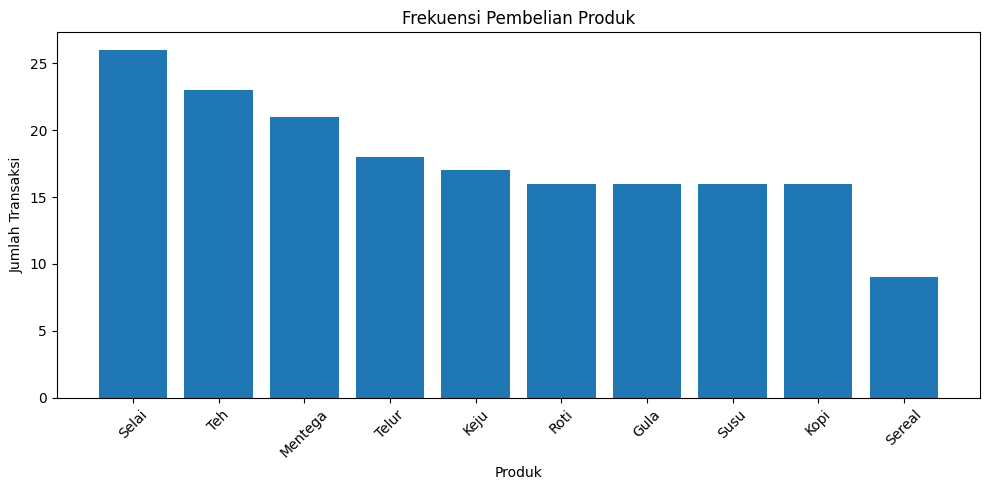

In [5]:
# Visualisasi frekuensi produk

plt.figure(figsize=(10, 5))

plt.bar(
    df_frekuensi['Produk'],
    df_frekuensi['Frekuensi']
)

plt.title('Frekuensi Pembelian Produk')
plt.xlabel('Produk')
plt.ylabel('Jumlah Transaksi')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. One-Hot Encoding Transaksi

Pada tahap ini, data transaksi diubah menjadi bentuk One-Hot Encoding
menggunakan TransactionEncoder.

Nilai True menunjukkan bahwa suatu produk terdapat dalam transaksi,
sedangkan False menunjukkan bahwa produk tidak terdapat dalam transaksi.

In [6]:
# Install mlxtend jika belum tersedia
%pip install -q mlxtend

# Import TransactionEncoder
from mlxtend.preprocessing import TransactionEncoder

print("TransactionEncoder berhasil diimpor.")

TransactionEncoder berhasil diimpor.


In [7]:
# Membuat objek TransactionEncoder
te = TransactionEncoder()

# Melakukan One-Hot Encoding
te_ary = te.fit(transaksi).transform(transaksi)

# Mengubah hasil encoding menjadi DataFrame
df_transaksi = pd.DataFrame(
    te_ary,
    columns=te.columns_
)

print("Hasil One-Hot Encoding:")
display(df_transaksi.head())

print("\nUkuran dataset:", df_transaksi.shape)

Hasil One-Hot Encoding:


,Gula,Keju,Kopi,Mentega,Roti,Selai,Sereal,Susu,Teh,Telur
0,False,True,True,True,True,True,False,False,False,False
1,False,False,True,True,True,True,False,False,True,False
2,False,False,True,False,False,False,False,True,True,False
3,False,True,False,False,False,True,False,False,True,True
4,True,True,False,True,False,False,False,True,False,False



Ukuran dataset: (50, 10)


## 3. Frequent Itemset dengan Apriori

Pada tahap ini digunakan algoritma Apriori untuk menemukan kombinasi produk
yang sering muncul secara bersamaan dalam transaksi.

Percobaan dilakukan menggunakan beberapa nilai minimum support, yaitu 0.05,
0.10, dan 0.20. Semakin kecil nilai minimum support, semakin banyak kombinasi
produk yang berpotensi ditemukan.

In [8]:
from mlxtend.frequent_patterns import apriori

# Menguji beberapa nilai minimum support
nilai_support = [0.05, 0.10, 0.20]

print("Jumlah frequent itemset berdasarkan minimum support:\n")

for ms in nilai_support:
    freq = apriori(
        df_transaksi,
        min_support=ms,
        use_colnames=True
    )

    print(f"min_support = {ms}: {len(freq)} itemset ditemukan")

Jumlah frequent itemset berdasarkan minimum support:

min_support = 0.05: 74 itemset ditemukan
min_support = 0.1: 44 itemset ditemukan
min_support = 0.2: 13 itemset ditemukan


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
# Membentuk frequent itemset dengan minimum support 0.10

freq_items = apriori(
    df_transaksi,
    min_support=0.10,
    use_colnames=True
)

# Mengurutkan berdasarkan support terbesar
freq_items = freq_items.sort_values(
    by='support',
    ascending=False
).reset_index(drop=True)

print("Frequent Itemset dengan min_support = 0.10:")
display(freq_items.head(10))

Frequent Itemset dengan min_support = 0.10:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,support,itemsets
0,0.52,(Selai)
1,0.46,(Teh)
2,0.42,(Mentega)
3,0.36,(Telur)
4,0.34,(Keju)
5,0.32,(Gula)
6,0.32,(Kopi)
7,0.32,(Roti)
8,0.32,(Susu)
9,0.24,"(Selai, Teh)"


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## 4. Membentuk & Menyaring Aturan Asosiasi

Frequent itemset yang telah diperoleh digunakan untuk membentuk aturan
asosiasi. Pada tahap ini digunakan metrik confidence untuk mengukur kekuatan
aturan dan lift untuk melihat hubungan antarproduk.

Aturan dengan nilai lift lebih dari 1 menunjukkan bahwa produk pada bagian
antecedent dan consequent memiliki hubungan positif.

In [10]:
from mlxtend.frequent_patterns import association_rules

# Membentuk aturan asosiasi berdasarkan confidence
rules = association_rules(
    freq_items,
    metric='confidence',
    min_threshold=0.5
)

# Menyaring aturan dengan lift > 1
rules = rules[rules['lift'] > 1]

# Mengurutkan berdasarkan lift tertinggi
rules = rules.sort_values(
    by='lift',
    ascending=False
).reset_index(drop=True)

print("Jumlah aturan asosiasi setelah penyaringan:", len(rules))

print("\n10 aturan dengan lift tertinggi:")
display(
    rules[
        ['antecedents', 'consequents',
         'support', 'confidence', 'lift']
    ].head(10)
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Jumlah aturan asosiasi setelah penyaringan: 16

10 aturan dengan lift tertinggi:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
0,"(Teh, Keju)",(Telur),0.12,0.857143,2.380952
1,"(Selai, Mentega)",(Kopi),0.10,0.625000,1.953125
2,"(Gula, Roti)",(Selai),0.10,1.000000,1.923077
3,(Sereal),(Mentega),0.14,0.777778,1.851852
4,"(Telur, Teh)",(Keju),0.12,0.600000,1.764706
5,"(Kopi, Selai)",(Mentega),0.10,0.714286,1.700680
6,"(Telur, Keju)",(Teh),0.12,0.750000,1.630435
7,"(Selai, Gula)",(Roti),0.10,0.500000,1.562500
8,"(Kopi, Mentega)",(Selai),0.10,0.714286,1.373626
9,(Roti),(Selai),0.22,0.687500,1.322115


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Interpretasi Association Rules

Aturan asosiasi diurutkan berdasarkan nilai lift tertinggi. Aturan dengan lift
lebih dari 1 menunjukkan adanya hubungan positif antara produk pada antecedent
dan consequent.

Aturan dengan lift tertinggi dapat dianggap sebagai aturan yang paling kuat
dalam dataset ini. Secara bisnis, aturan tersebut dapat digunakan sebagai dasar
untuk memberikan rekomendasi produk atau membuat strategi bundling.

Pola Roti dan Selai juga menjadi perhatian karena pada tahap pembuatan dataset
telah disuntikkan pola bahwa Roti sering dibeli bersama Selai. Oleh karena itu,
hubungan antara kedua produk tersebut diharapkan dapat muncul dalam hasil
association rules.

## 5. Rekomender Sederhana dengan Content-Based Filtering

Pada tahap ini dibuat katalog produk yang berisi nama produk dan kategori.
Rekomendasi produk dilakukan berdasarkan kemiripan kategori menggunakan
Cosine Similarity.

Produk yang memiliki kategori sama akan memiliki tingkat kemiripan yang lebih
tinggi dibandingkan produk dari kategori yang berbeda.

In [11]:
from sklearn.metrics.pairwise import cosine_similarity

# Membuat katalog produk
katalog = pd.DataFrame({
    'produk': produk,
    'kategori': [
        'Bakery', 'Bakery', 'Dairy', 'Bakery', 'Dairy',
        'Dairy', 'Minuman', 'Bumbu', 'Minuman', 'Dairy'
    ]
})

print("Katalog Produk:")
display(katalog)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Katalog Produk:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,produk,kategori
0,Roti,Bakery
1,Selai,Bakery
2,Susu,Dairy
3,Sereal,Bakery
4,Telur,Dairy
5,Keju,Dairy
6,Kopi,Minuman
7,Gula,Bumbu
8,Teh,Minuman
9,Mentega,Dairy


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [12]:
# One-Hot Encoding kategori
fitur = pd.get_dummies(katalog['kategori'])

print("Fitur One-Hot Kategori:")
display(fitur)

# Menghitung Cosine Similarity
sim_matrix = cosine_similarity(fitur)

print("Ukuran matriks similarity:", sim_matrix.shape)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Fitur One-Hot Kategori:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Bakery,Bumbu,Dairy,Minuman
0,True,False,False,False
1,True,False,False,False
2,False,False,True,False
3,True,False,False,False
4,False,False,True,False
5,False,False,True,False
6,False,False,False,True
7,False,True,False,False
8,False,False,False,True
9,False,False,True,False


Ukuran matriks similarity: (10, 10)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [13]:
def rekomendasi_serupa(nama_produk, top_n=3):
    # Memastikan produk tersedia
    if nama_produk not in katalog['produk'].values:
        return []

    # Mendapatkan index produk
    idx = katalog.index[
        katalog['produk'] == nama_produk
    ][0]

    # Mengambil skor similarity
    skor = list(enumerate(sim_matrix[idx]))

    # Mengurutkan dari similarity tertinggi
    skor = sorted(
        skor,
        key=lambda x: x[1],
        reverse=True
    )

    # Menghapus produk itu sendiri
    skor = [
        s for s in skor
        if s[0] != idx
    ][:top_n]

    # Mengambil nama produk
    hasil = katalog.iloc[
        [i for i, _ in skor]
    ]['produk'].tolist()

    return hasil


# Contoh rekomendasi
print("Rekomendasi produk yang mirip dengan Roti:")
print(rekomendasi_serupa('Roti'))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Rekomendasi produk yang mirip dengan Roti:
['Selai', 'Sereal', 'Susu']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## 6. Perbandingan Association Rules dan Content-Based Filtering

Pada tahap ini dibandingkan hasil rekomendasi dari dua pendekatan, yaitu
Association Rules dan Content-Based Filtering untuk produk yang sama.

Association Rules menggunakan pola pembelian dari data transaksi, sedangkan
Content-Based Filtering menggunakan kemiripan kategori produk.

In [14]:
produk_target = 'Roti'

# Mencari aturan yang antecedent-nya mengandung produk target
rules_terkait = rules[
    rules['antecedents'].apply(
        lambda x: produk_target in x
    )
]

print(f"Produk target: {produk_target}")

print("\nRekomendasi dari Association Rules:")

if len(rules_terkait) > 0:
    display(
        rules_terkait[
            ['antecedents', 'consequents',
             'support', 'confidence', 'lift']
        ].head(10)
    )
else:
    print("Tidak ditemukan aturan asosiasi untuk produk target.")

print("\nRekomendasi dari Content-Based Filtering:")
print(rekomendasi_serupa(produk_target))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Produk target: Roti

Rekomendasi dari Association Rules:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
2,"(Gula, Roti)",(Selai),0.10,1.0000,1.923077
9,(Roti),(Selai),0.22,0.6875,1.322115



Rekomendasi dari Content-Based Filtering:
['Selai', 'Sereal', 'Susu']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Diskusi

Kedua pendekatan memiliki dasar rekomendasi yang berbeda. Association Rules
memberikan rekomendasi berdasarkan pola pembelian yang ditemukan dalam data
transaksi. Pendekatan ini lebih sesuai ketika tersedia data transaksi pelanggan
yang cukup banyak.

Sementara itu, Content-Based Filtering memberikan rekomendasi berdasarkan
kemiripan karakteristik produk, dalam praktikum ini menggunakan kategori.
Pendekatan ini dapat digunakan meskipun belum tersedia banyak data transaksi,
tetapi kualitas rekomendasi sangat bergantung pada kelengkapan atribut produk.

Kedua pendekatan dapat digabungkan menjadi sistem rekomendasi hybrid.
Association Rules dapat digunakan untuk memanfaatkan pola pembelian,
sedangkan Content-Based Filtering dapat digunakan untuk mencari produk yang
memiliki karakteristik serupa.

## Kesimpulan

Pada praktikum ini telah dipelajari penerapan Market Basket Analysis
menggunakan algoritma Apriori dan pembangunan rekomendasi produk menggunakan
Content-Based Filtering. Algoritma Apriori digunakan untuk menemukan frequent
itemset dan aturan asosiasi berdasarkan nilai support, confidence, dan lift.

Hasil analisis menunjukkan adanya pola hubungan antarproduk dalam transaksi.
Selain itu, Content-Based Filtering menggunakan Cosine Similarity mampu
memberikan rekomendasi berdasarkan kesamaan kategori produk.

Perbedaan utama kedua pendekatan adalah Association Rules menggunakan pola
pembelian aktual, sedangkan Content-Based Filtering menggunakan karakteristik
produk. Keduanya dapat digabungkan dalam sistem rekomendasi hybrid untuk
menghasilkan rekomendasi yang lebih beragam.

Keterbatasan praktikum ini adalah dataset yang digunakan masih sintetis dan
hanya terdiri dari 50 transaksi serta 10 produk. Oleh karena itu, hasil yang
diperoleh belum tentu menggambarkan pola pembelian pelanggan sebenarnya.
Pengembangan selanjutnya dapat menggunakan dataset transaksi yang lebih besar,
atribut produk yang lebih lengkap, dan metode hybrid.